In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import randint, uniform
import optuna
import joblib

from pprint import pprint

from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier, early_stopping

from models.model_pipelines import (
    make_logreg_pipeline, 
    make_gb_pipeline, 
    EnsembleClassifier,
    BoostingClassifier
)

/home/alex/projects/tf_cuda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fe_train_df = pd.read_csv('data/fe_new/train.csv')
fe_val_df = pd.read_csv('data/fe_new/val.csv') 
fe_test_df = pd.read_csv('data/fe_new/test.csv')

In [3]:
fe2_fs_train_df = pd.read_csv('data/fe2_fs_new/train.csv')
fe2_fs_val_df = pd.read_csv('data/fe2_fs_new/val.csv')
fe2_fs_test_df = pd.read_csv('data/fe2_fs_new/test.csv')

In [4]:
def split_xy(df, target_col='SeriousDlqin2yrs'):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y

In [5]:
X_fe_train, y_fe_train = split_xy(fe_train_df)
X_fe_val, y_fe_val = split_xy(fe_val_df)
X_fe_test, y_fe_test = split_xy(fe_test_df)

In [6]:
X_fe2_fs_train, y_fe2_fs_train = split_xy(fe2_fs_train_df)
X_fe2_fs_val, y_fe2_fs_val = split_xy(fe2_fs_val_df)
X_fe2_fs_test, y_fe2_fs_test = split_xy(fe2_fs_test_df)

In [7]:
def evaluate_model(
    model, 
    X, y,
    threshold=0.5
):
    probs = model.predict_proba(X)[:, 1]
    
    preds = (probs >= threshold).astype(int)

    metrics = {
        'BCE': log_loss(y, probs),
        'AUC': roc_auc_score(y, probs),
        'Accuracy': accuracy_score(y, preds),
        'Precision': precision_score(y, preds, zero_division=0),
        'Recall': recall_score(y, preds, zero_division=0),
        'F1': f1_score(y, preds, zero_division=0),
    }

    return metrics

In [10]:
gbm_pipe = make_gb_pipeline(
    GradientBoostingClassifier()
)

In [11]:
logreg_pipe = make_logreg_pipeline(
    LogisticRegression()
)

In [12]:
lgbm_pipe = make_gb_pipeline(
    LGBMClassifier(verbose=0)
)

In [13]:
gbm_pipe.fit(X_fe2_fs_train, y_fe2_fs_train)

gbm_metrics = evaluate_model(
    gbm_pipe,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(gbm_metrics)

{'AUC': 0.860399368750076,
 'Accuracy': 0.9368444444444445,
 'BCE': 0.17947528761293194,
 'F1': 0.29548834903321763,
 'Precision': 0.580896686159844,
 'Recall': 0.1981382978723404}


In [14]:
joblib.dump(gbm_pipe, 'models/GBM/gbm.joblib')

['models/GBM/gbm.joblib']

In [16]:
gbm_pipe = joblib.load('models/GBM/gbm.joblib')

In [16]:
logreg_pipe.fit(X_fe_train, y_fe_train)

logreg_metrics = evaluate_model(
    logreg_pipe,
    X_fe_test, y_fe_test
)
pprint(logreg_metrics)

{'AUC': 0.8570256891636908,
 'Accuracy': 0.9378222222222222,
 'BCE': 0.18837925424443214,
 'F1': 0.3001500750375188,
 'Precision': 0.6060606060606061,
 'Recall': 0.19946808510638298}


In [17]:
joblib.dump(logreg_pipe, 'models/LogReg/logreg.joblib')

['models/LogReg/logreg.joblib']

In [18]:
logreg_pipe = joblib.load('models/LogReg/logreg.joblib')

In [19]:
lgbm_pipe.fit(X_fe2_fs_train, y_fe2_fs_train)

lgbm_metrics = evaluate_model(
    lgbm_pipe,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(lgbm_metrics)

{'AUC': 0.860223835061795,
 'Accuracy': 0.9371555555555555,
 'BCE': 0.17913409666376748,
 'F1': 0.28585858585858587,
 'Precision': 0.5945378151260504,
 'Recall': 0.18816489361702127}


In [20]:
joblib.dump(lgbm_pipe, 'models/LGBM/lgbm.joblib')

['models/LGBM/lgbm.joblib']

In [20]:
lgbm_pipe = joblib.load('models/LGBM/lgbm.joblib')

In [22]:
def plot_roc_curve(model, model_name, X, y):
    plt.figure(figsize=(6, 6))
    probs = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, probs)
    auc_score = roc_auc_score(y, probs)

    plt.plot(fpr, tpr, label=f'AUC={auc_score:.4f}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC-AUC')
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(alpha=0.3)
    plt.show()

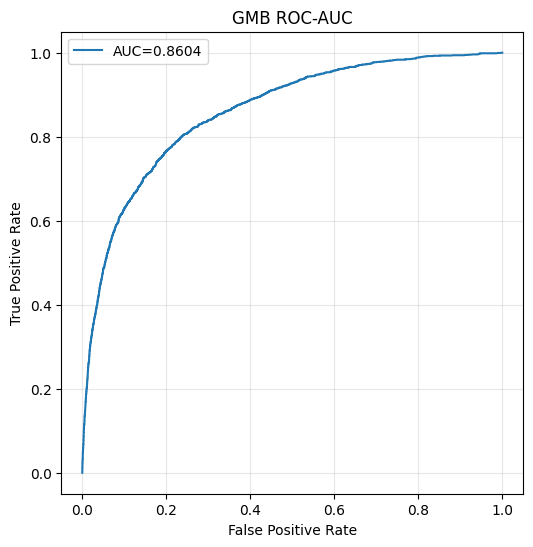

In [23]:
plot_roc_curve(gbm_pipe, 'GMB', X_fe2_fs_test, y_fe2_fs_test)

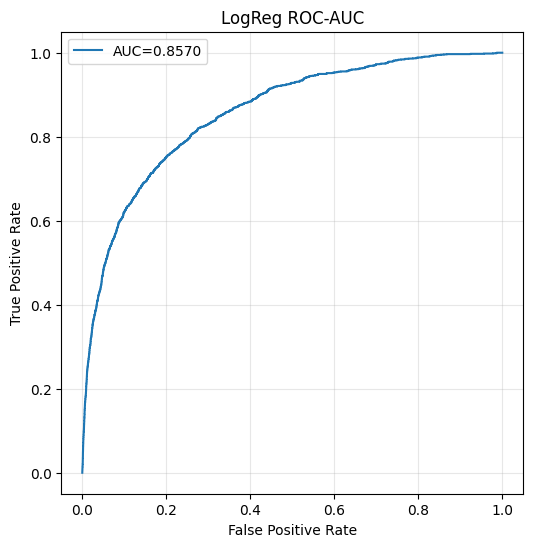

In [24]:
plot_roc_curve(logreg_pipe, 'LogReg', X_fe_test, y_fe_test)

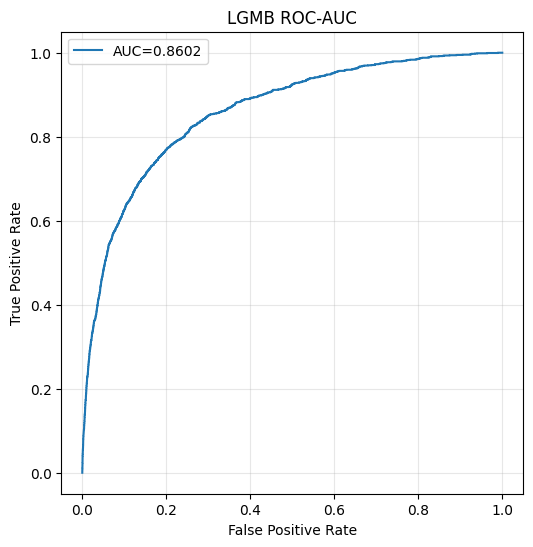

In [25]:
plot_roc_curve(lgbm_pipe, 'LGMB', X_fe2_fs_test, y_fe2_fs_test)

In [31]:
metrics_dict = {
    'GBM': gbm_metrics,
    'LogReg': logreg_metrics,
    'LGBM': lgbm_metrics
}

In [33]:
def plot_metrics_from_dicts(metrics_dict):
    metrics = ['BCE', 'AUC', 'F1', 'Accuracy', 'Precision', 'Recall']

    df = pd.DataFrame(metrics_dict).T
    df = df[metrics]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        values = df[metric]
        models = df.index

        if metric == 'BCE':
            best_model = values.idxmin()
        else:
            best_model = values.idxmax()

        colors = ['tab:orange' if model == best_model else 'tab:blue' for model in models]

        ax.bar(models, values, color=colors)

        y_min = values.min()
        y_max = values.max()
        margin = (y_max - y_min) * 0.3 if y_max != y_min else 0.01
        ax.set_ylim(y_min - margin, y_max + margin)

        ax.set_title(metric)
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=20)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

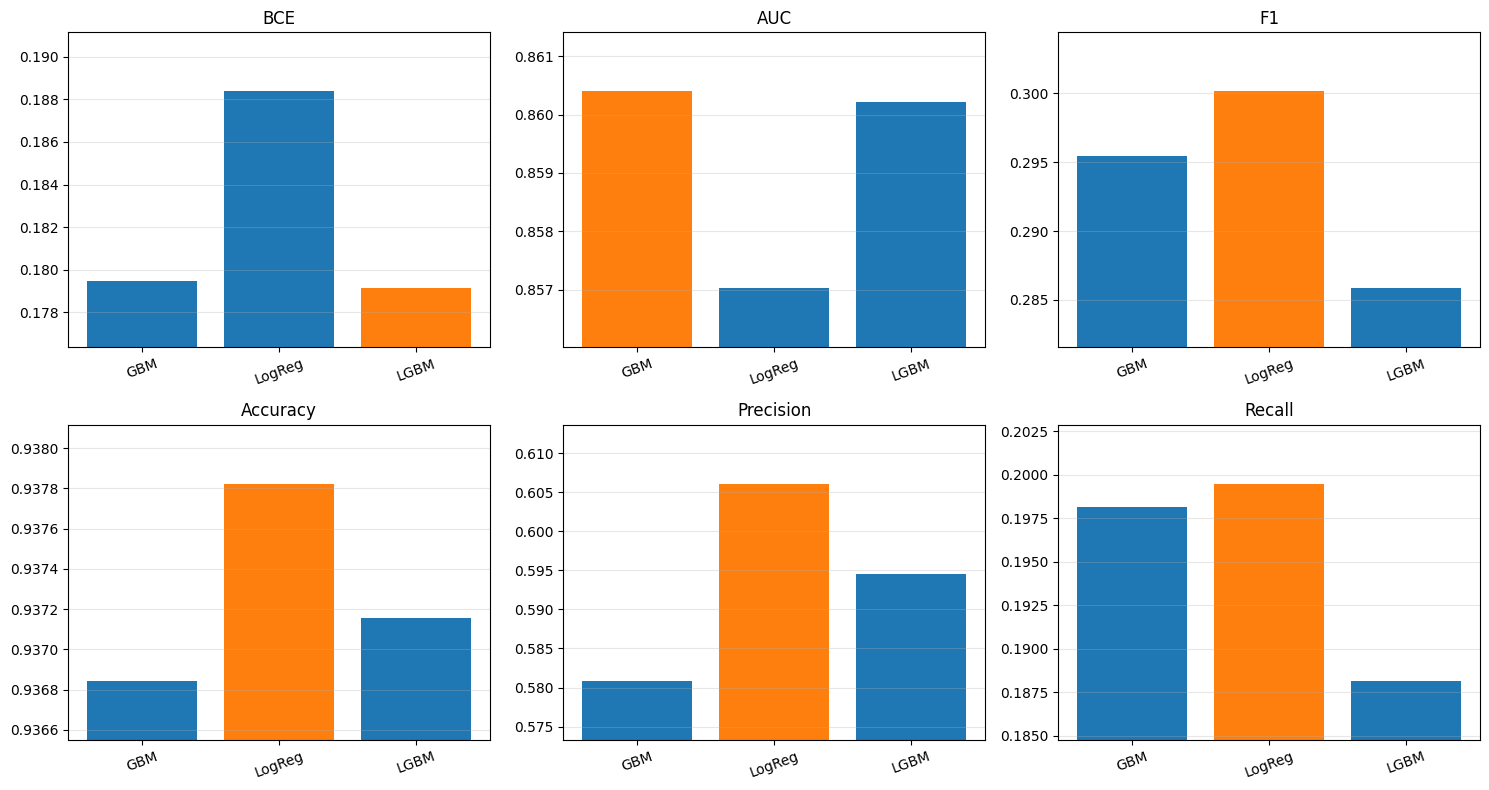

In [28]:
plot_metrics_from_dicts(metrics_dict)

In [29]:
gbm_pipe_gscv = make_gb_pipeline(
    GradientBoostingClassifier(random_state=42)
)

param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__subsample': [0.8, 1.0],
}

grid = GridSearchCV(
    estimator=gbm_pipe_gscv,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=0
)


grid.fit(X_fe2_fs_train, y_fe2_fs_train)
print(f'Лучшие параметры: {grid.best_params_}')

gbm_pipe_gscv = grid.best_estimator_

gbm_gscv_metrics = evaluate_model(
    gbm_pipe_gscv,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(gbm_gscv_metrics)

Лучшие параметры: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
{'AUC': 0.861645236757356,
 'Accuracy': 0.9365333333333333,
 'BCE': 0.17910813518592633,
 'F1': 0.2736520854526958,
 'Precision': 0.5822510822510822,
 'Recall': 0.17885638297872342}


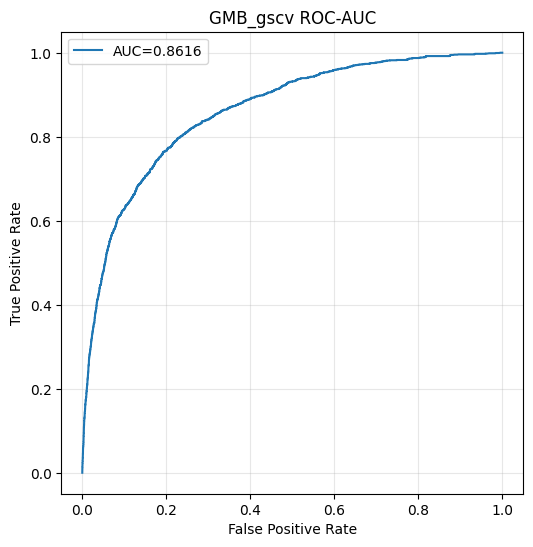

In [30]:
plot_roc_curve(gbm_pipe_gscv, 'GMB_gscv', X_fe2_fs_test, y_fe2_fs_test)

In [31]:
joblib.dump(gbm_pipe_gscv, 'models/GBM/gbm_gscv.joblib')

['models/GBM/gbm_gscv.joblib']

In [22]:
gbm_pipe_gscv = joblib.load('models/GBM/gbm_gscv.joblib')

In [33]:
def objective_gbm(trial):
    params = {
        'model__n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'model__max_depth': trial.suggest_int('max_depth', 2, 5),
        'model__subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'model__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 30), 
        'model__random_state': 42
    }

    pipe = make_gb_pipeline(
        GradientBoostingClassifier()
    )

    pipe.set_params(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    score = cross_val_score(
        pipe,
        X_fe2_fs_train,
        y_fe2_fs_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    ).mean()

    return score

In [34]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_gbm, n_trials=50)

best_params = {
    f'model__{k}': v for k, v in study.best_params.items()
}
print(f'Лучшие параметры: {best_params}')


gbm_pipe_optuna = make_gb_pipeline(
    GradientBoostingClassifier()
)
gbm_pipe_optuna.set_params(**best_params)

gbm_pipe_optuna.fit(X_fe2_fs_train, y_fe2_fs_train) 

gbm_optuna_metrics = evaluate_model(
    gbm_pipe_optuna,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(gbm_optuna_metrics)

[I 2026-04-07 20:29:30,803] A new study created in memory with name: no-name-9bb2dc48-c3be-4272-9b39-8bebf67e1e77
[I 2026-04-07 20:30:08,132] Trial 0 finished with value: 0.8631296324299645 and parameters: {'n_estimators': 238, 'learning_rate': 0.05683941394479807, 'max_depth': 5, 'subsample': 0.8981033239716121, 'min_samples_split': 29, 'min_samples_leaf': 19}. Best is trial 0 with value: 0.8631296324299645.
[I 2026-04-07 20:30:36,826] Trial 1 finished with value: 0.8621849955728891 and parameters: {'n_estimators': 195, 'learning_rate': 0.0205732186331223, 'max_depth': 4, 'subsample': 0.985292914240627, 'min_samples_split': 30, 'min_samples_leaf': 12}. Best is trial 0 with value: 0.8631296324299645.
[I 2026-04-07 20:31:04,953] Trial 2 finished with value: 0.8626933542818305 and parameters: {'n_estimators': 300, 'learning_rate': 0.0196016285864564, 'max_depth': 3, 'subsample': 0.87531831390426, 'min_samples_split': 21, 'min_samples_leaf': 28}. Best is trial 0 with value: 0.863129632429

Лучшие параметры: {'model__n_estimators': 118, 'model__learning_rate': 0.10807207638281235, 'model__max_depth': 3, 'model__subsample': 0.8161688758420045, 'model__min_samples_split': 42, 'model__min_samples_leaf': 18}
{'AUC': 0.8612383393442722,
 'Accuracy': 0.9369333333333333,
 'BCE': 0.17905666169898807,
 'F1': 0.287292817679558,
 'Precision': 0.5872689938398358,
 'Recall': 0.1901595744680851}


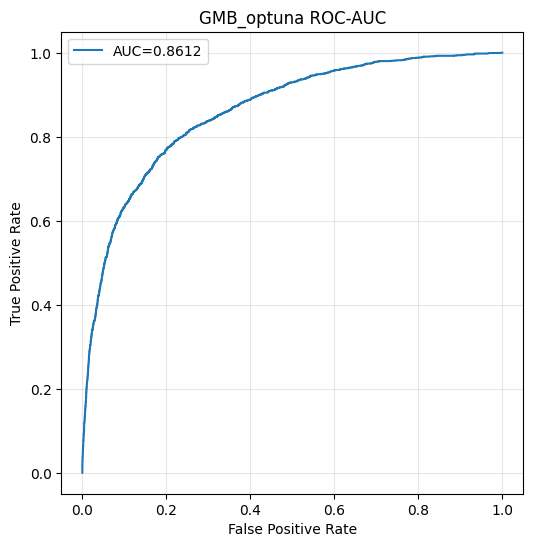

In [35]:
plot_roc_curve(gbm_pipe_optuna, 'GMB_optuna', X_fe2_fs_test, y_fe2_fs_test)

In [36]:
joblib.dump(gbm_pipe_optuna, 'models/GBM/gbm_optuna.joblib')

['models/GBM/gbm_optuna.joblib']

In [24]:
gbm_pipe_optuna = joblib.load('models/GBM/gbm_optuna.joblib')

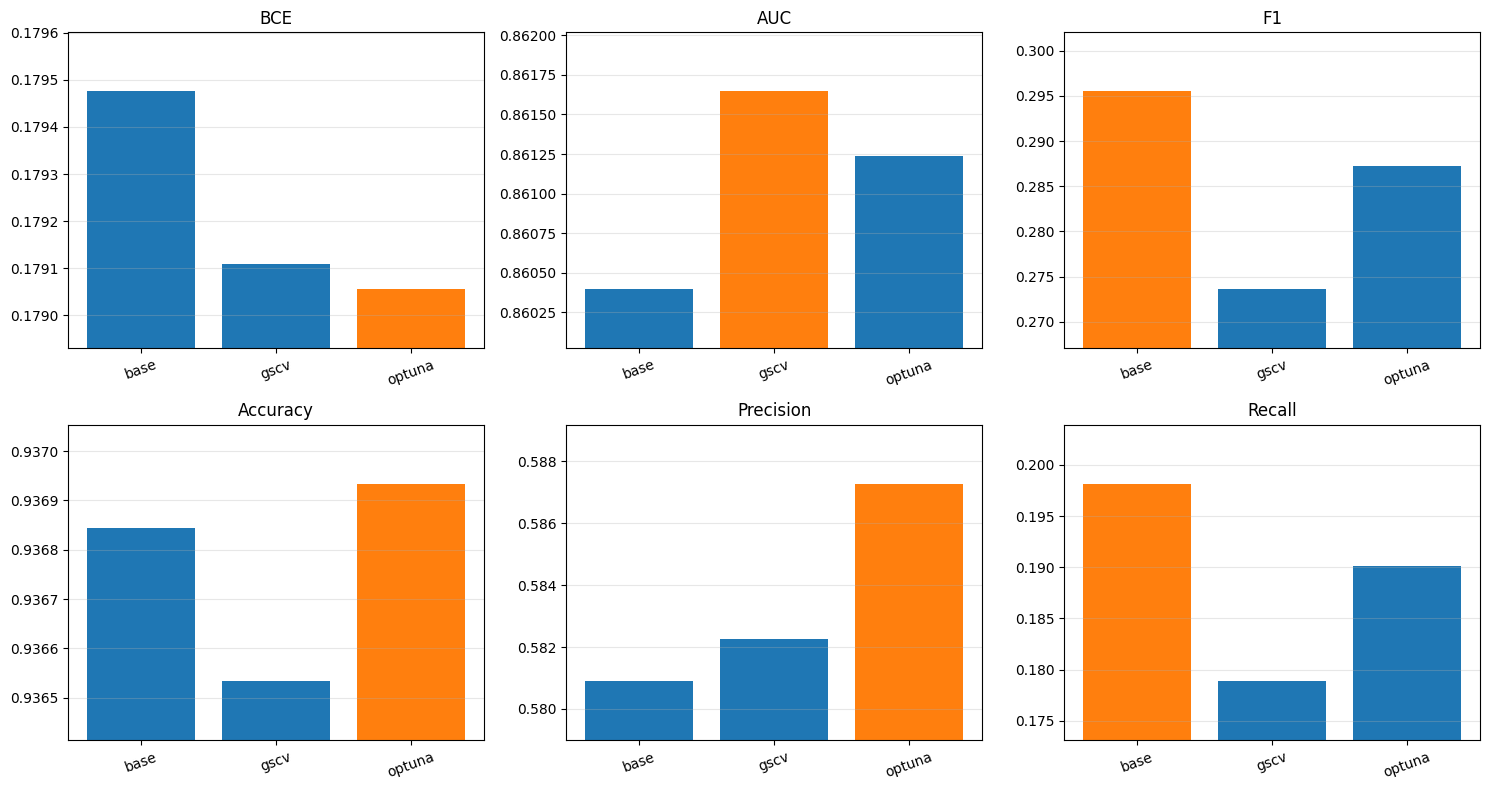

In [36]:
metrics_dict = {
    'base': gbm_metrics,
    'gscv': gbm_gscv_metrics,
    'optuna': gbm_optuna_metrics
}

plot_metrics_from_dicts(metrics_dict)

In [39]:
logreg_pipe_gscv = make_logreg_pipeline(
    LogisticRegression()
)

param_grid = [
    {
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs', 'liblinear'],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__class_weight': [None, 'balanced'],
    },
    {
        'model__penalty': ['l1'],
        'model__solver': ['liblinear'],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__class_weight': [None, 'balanced'],
    }
]

grid = GridSearchCV(
    estimator=logreg_pipe_gscv,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=0
)


grid.fit(X_fe_train, y_fe_train)
print(f'Лучшие параметры: {grid.best_params_}')

logreg_pipe_gscv = grid.best_estimator_

logreg_gscv_metrics = evaluate_model(
    logreg_pipe_gscv,
    X_fe_test, y_fe_test
)
pprint(logreg_gscv_metrics)

Лучшие параметры: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
{'AUC': 0.8571298756754073,
 'Accuracy': 0.8076888888888889,
 'BCE': 0.47822902727553407,
 'F1': 0.33928844098335625,
 'Precision': 0.22021803766105055,
 'Recall': 0.7386968085106383}


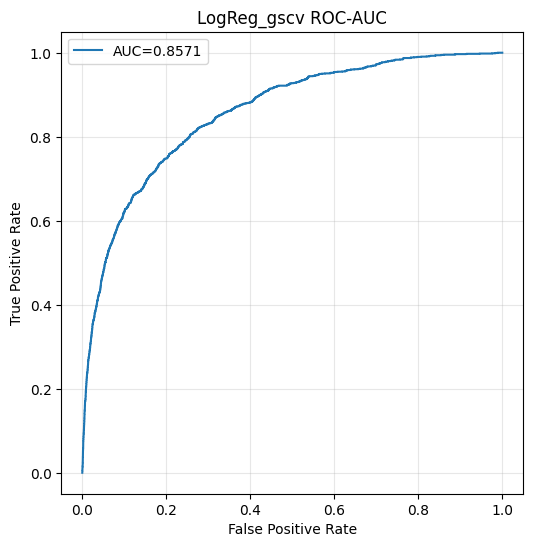

In [40]:
plot_roc_curve(logreg_pipe_gscv, 'LogReg_gscv', X_fe_test, y_fe_test)

In [41]:
joblib.dump(logreg_pipe_gscv, 'models/LogReg/logreg_gscv.joblib')

['models/LogReg/logreg_gscv.joblib']

In [26]:
logreg_pipe_gscv = joblib.load('models/LogReg/logreg_gscv.joblib')

In [43]:
def objective_logreg(trial):
    params = {
        'model__C': trial.suggest_float('C', 1e-3, 1e2, log=True),
        'model__penalty': 'l2',
        'model__solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear']),
        'model__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'model__max_iter': 2000,
        'model__random_state': 42
    }

    pipe = make_logreg_pipeline(
        LogisticRegression()
    )

    pipe.set_params(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        pipe,
        X_fe_train,
        y_fe_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    ).mean()

    return score

In [44]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_logreg, n_trials=50)

best_params = {
    f'model__{k}': v for k, v in study.best_params.items()
}
print(f'Лучшие параметры: {best_params}')


logreg_pipe_optuna = make_logreg_pipeline(
    LogisticRegression()
)
logreg_pipe_optuna.set_params(**best_params)

logreg_pipe_optuna.fit(X_fe_train, y_fe_train) 

logreg_optuna_metrics = evaluate_model(
    logreg_pipe_optuna,
    X_fe_test, y_fe_test
)
pprint(logreg_optuna_metrics)

[I 2026-04-07 20:48:39,206] A new study created in memory with name: no-name-c66216c1-5aa8-4f2d-bab6-d34a22961f8d
[I 2026-04-07 20:48:39,688] Trial 0 finished with value: 0.8575760725265832 and parameters: {'C': 0.11199778820383266, 'solver': 'liblinear', 'class_weight': None}. Best is trial 0 with value: 0.8575760725265832.
[I 2026-04-07 20:48:40,176] Trial 1 finished with value: 0.857340495106864 and parameters: {'C': 0.006631605425642359, 'solver': 'lbfgs', 'class_weight': None}. Best is trial 0 with value: 0.8575760725265832.
[I 2026-04-07 20:48:40,634] Trial 2 finished with value: 0.8575973629940872 and parameters: {'C': 0.16636086016120713, 'solver': 'liblinear', 'class_weight': None}. Best is trial 2 with value: 0.8575973629940872.
[I 2026-04-07 20:48:41,655] Trial 3 finished with value: 0.8576115020455186 and parameters: {'C': 1.8470498953506262, 'solver': 'liblinear', 'class_weight': None}. Best is trial 3 with value: 0.8576115020455186.
[I 2026-04-07 20:48:42,204] Trial 4 fin

Лучшие параметры: {'model__C': 2.4977997404296786, 'model__solver': 'lbfgs', 'model__class_weight': 'balanced'}
{'AUC': 0.857138710944942,
 'Accuracy': 0.8077777777777778,
 'BCE': 0.47813770627136853,
 'F1': 0.33898823169799785,
 'Precision': 0.22008334987100614,
 'Recall': 0.7373670212765957}


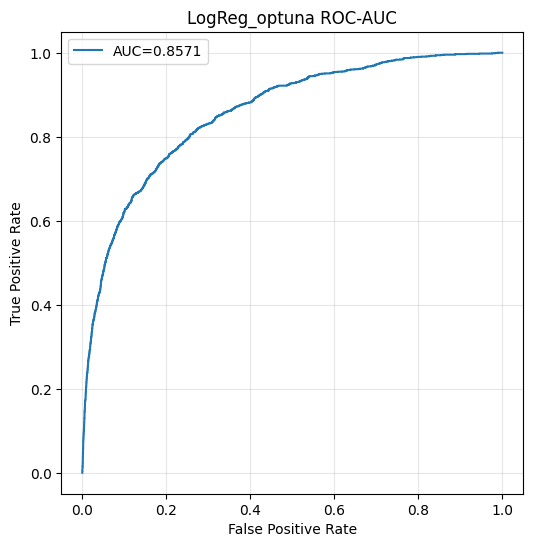

In [45]:
plot_roc_curve(logreg_pipe_optuna, 'LogReg_optuna', X_fe_test, y_fe_test)

In [46]:
joblib.dump(logreg_pipe_optuna, 'models/LogReg/logreg_optuna.joblib')

['models/LogReg/logreg_optuna.joblib']

In [28]:
logreg_pipe_optuna = joblib.load('models/LogReg/logreg_optuna.joblib')

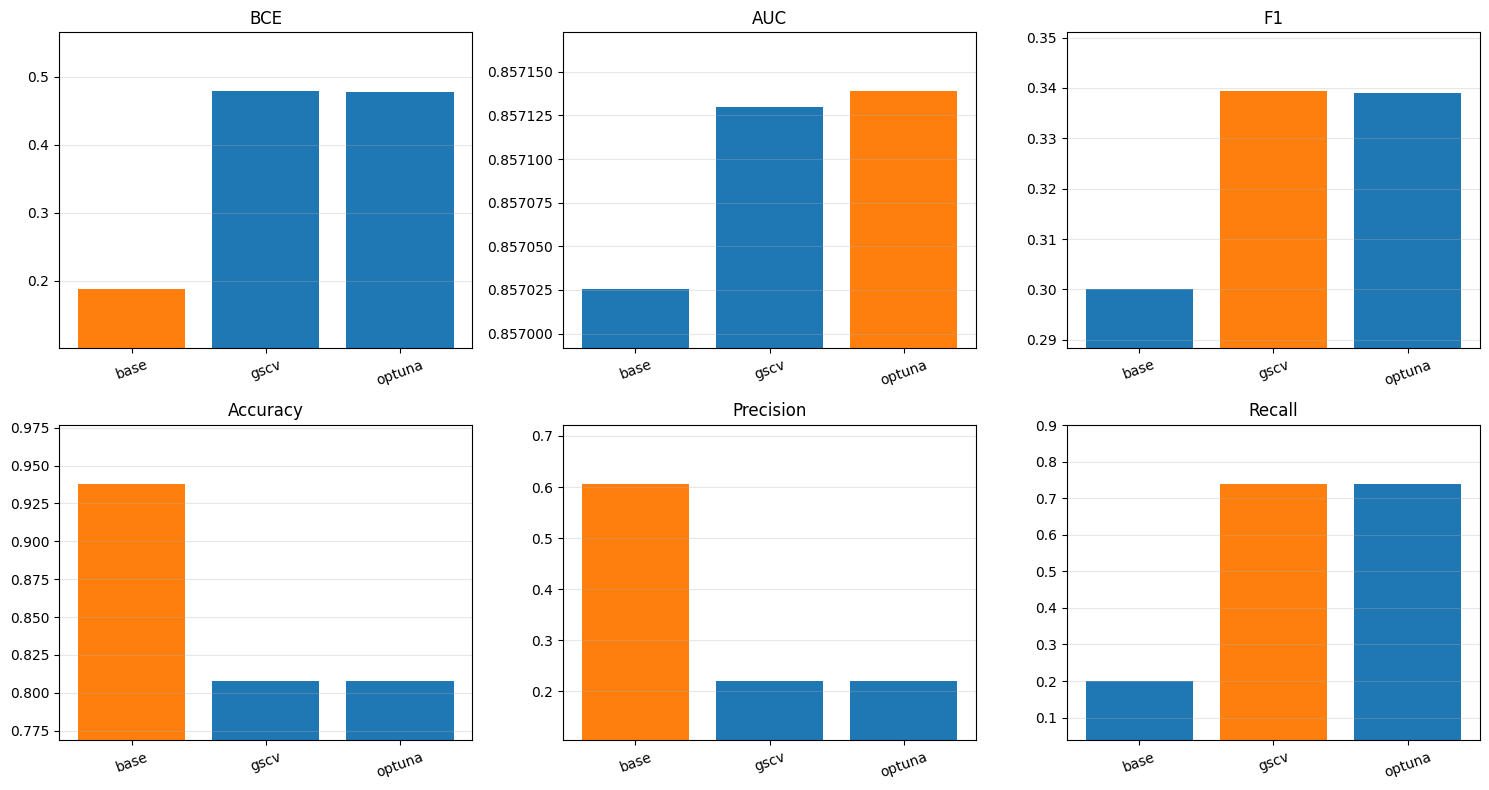

In [39]:
metrics_dict = {
    'base': logreg_metrics,
    'gscv': logreg_gscv_metrics,
    'optuna': logreg_optuna_metrics
}

plot_metrics_from_dicts(metrics_dict)

In [53]:
def objective_lgbm(trial):
    max_depth = trial.suggest_int('max_depth', 3, 6)
    max_leaves = min(2 ** max_depth, 64)

    params = {
        'model__n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'model__max_depth': max_depth,
        'model__num_leaves': trial.suggest_int('num_leaves', 4, max_leaves),
        'model__subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'model__colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0),
        'model__min_child_samples': trial.suggest_int('min_child_samples', 20, 60),
        'model__reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        'model__reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 1.0, log=True),
        'model__random_state': 42,
        'model__verbose': 0,
        'model__objective': 'binary',
        'model__n_jobs': 6
    }

    pipe = make_gb_pipeline(
        LGBMClassifier()
    )

    pipe.set_params(**params)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    score = cross_val_score(
        pipe,
        X_fe2_fs_train,
        y_fe2_fs_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=6
    ).mean()

    return score

In [54]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_lgbm, n_trials=50)

best_params = {
    f'model__{k}': v for k, v in study.best_params.items()
}
print(f'Лучшие параметры: {best_params}')


lgbm_pipe_optuna = make_gb_pipeline(
    LGBMClassifier()
)
lgbm_pipe_optuna.set_params(**best_params)

lgbm_pipe_optuna.fit(X_fe2_fs_train, y_fe2_fs_train) 

lgbm_optuna_metrics = evaluate_model(
    lgbm_pipe_optuna,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(lgbm_optuna_metrics)

[I 2026-04-07 21:03:03,254] A new study created in memory with name: no-name-39bd7bed-0e9d-43d3-be71-5a20ce6b2950
[I 2026-04-07 21:03:06,475] Trial 0 finished with value: 0.8489051343155367 and parameters: {'max_depth': 3, 'n_estimators': 50, 'learning_rate': 0.012797652768010474, 'num_leaves': 6, 'subsample': 0.807665952728192, 'colsample_bytree': 0.9430250031853347, 'min_child_samples': 21, 'reg_alpha': 0.016572403586979652, 'reg_lambda': 0.20580459618653618}. Best is trial 0 with value: 0.8489051343155367.
[I 2026-04-07 21:03:07,796] Trial 1 finished with value: 0.8589716083200049 and parameters: {'max_depth': 3, 'n_estimators': 62, 'learning_rate': 0.039699395663702536, 'num_leaves': 8, 'subsample': 0.9078975354371336, 'colsample_bytree': 0.9769653363518951, 'min_child_samples': 54, 'reg_alpha': 0.035266515449222595, 'reg_lambda': 0.009765108335572023}. Best is trial 1 with value: 0.8589716083200049.
[I 2026-04-07 21:03:08,218] Trial 2 finished with value: 0.8565218228427837 and pa

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-07 21:03:34,359] Trial 19 finished with value: 0.862938124199277 and parameters: {'max_depth': 5, 'n_estimators': 149, 'learning_rate': 0.048997466093526926, 'num_leaves': 29, 'subsample': 0.9351263054962721, 'colsample_bytree': 0.9963949969447716, 'min_child_samples': 22, 'reg_alpha': 0.002569625901772371, 'reg_lambda': 0.028747308139558832}. Best is trial 18 with value: 0.8640650915920082.
[I 2026-04-07 21:03:36,207] Trial 20 finished with value: 0.8572132405233837 and parameters: {'max_depth': 3, 'n_estimators': 150, 'learning_rate': 0.012795513945327533, 'num_leaves': 7, 'subsample': 0.8868353964634897, 'colsample_bytree': 0.9998324524813773, 'min_child_samples': 25, 'reg_alpha': 0.2316468611766146, 'reg_lambda': 0.004483679962378602}. Best is trial 18 with value: 0.8640650915920082.
[I 2026-04-07 21:03:37,782] Trial 21 finished with value: 0.8640715252873958 and parameters: {'max_depth': 4, 'n_estimators': 123, 'learning_rate': 0.07179358826605278, 'num_leaves': 9, 'sub

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-07 21:03:47,450] Trial 25 finished with value: 0.8640226799134263 and parameters: {'max_depth': 4, 'n_estimators': 111, 'learning_rate': 0.08092242887503652, 'num_leaves': 8, 'subsample': 0.9572135830067308, 'colsample_bytree': 0.8691649699146948, 'min_child_samples': 20, 'reg_alpha': 0.9009523413938819, 'reg_lambda': 0.003147842879231144}. Best is trial 21 with value: 0.8640715252873958.
[I 2026-04-07 21:03:48,920] Trial 26 finished with value: 0.864205908967613 and parameters: {'max_depth': 4, 'n_estimators': 128, 'learning_rate': 0.07450187629374308, 'num_leaves': 11, 'subsample': 0.9825059527085601, 'colsample_bytree': 0.8689744462304861, 'min_child_samples': 26, 'reg_alpha': 0.7805271062662581, 'reg_lambda': 0.003021065032721861}. Best is trial 26 with value: 0.864205908967613.
[I 2026-04-07 21:03:52,227] Trial 27 finished with value: 0.8638598326259554 and parameters: {'max_depth': 5, 'n_estimators': 129, 'learning_rate': 0.061023511301065564, 'num_leaves': 15, 'subsam

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-07 21:04:18,995] Trial 39 finished with value: 0.8627033647296262 and parameters: {'max_depth': 3, 'n_estimators': 141, 'learning_rate': 0.03935544502997088, 'num_leaves': 6, 'subsample': 0.945334101404205, 'colsample_bytree': 0.8980541852151206, 'min_child_samples': 35, 'reg_alpha': 0.7070508755902156, 'reg_lambda': 0.011044370815942634}. Best is trial 32 with value: 0.8643112239333771.
[I 2026-04-07 21:04:21,159] Trial 40 finished with value: 0.8572308125392737 and parameters: {'max_depth': 4, 'n_estimators': 133, 'learning_rate': 0.010856642913994428, 'num_leaves': 8, 'subsample': 0.9870458595905878, 'colsample_bytree': 0.9379796481592417, 'min_child_samples': 53, 'reg_alpha': 0.20537525172528698, 'reg_lambda': 0.035719888633162465}. Best is trial 32 with value: 0.8643112239333771.
[I 2026-04-07 21:04:22,740] Trial 41 finished with value: 0.8639286821618289 and parameters: {'max_depth': 4, 'n_estimators': 126, 'learning_rate': 0.06962676088195759, 'num_leaves': 7, 'subsam

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-07 21:04:40,190] Trial 49 finished with value: 0.8592052228402696 and parameters: {'max_depth': 6, 'n_estimators': 111, 'learning_rate': 0.12459500069942021, 'num_leaves': 59, 'subsample': 0.9240280642531329, 'colsample_bytree': 0.9146691845649618, 'min_child_samples': 22, 'reg_alpha': 0.42774978589823504, 'reg_lambda': 0.005495628314863147}. Best is trial 32 with value: 0.8643112239333771.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

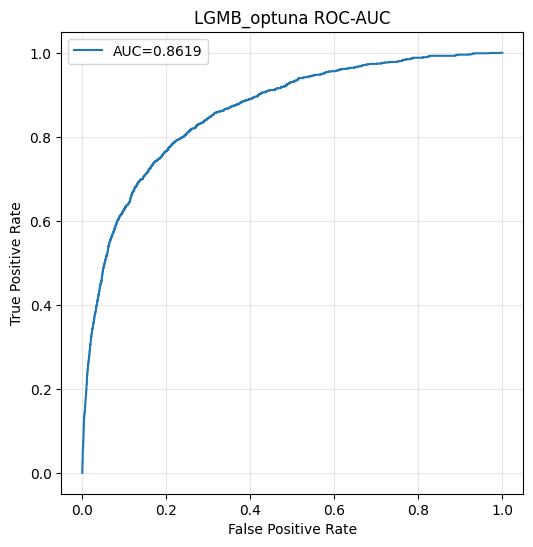

In [55]:
plot_roc_curve(lgbm_pipe_optuna, 'LGMB_optuna', X_fe2_fs_test, y_fe2_fs_test)

In [56]:
joblib.dump(lgbm_pipe_optuna, 'models/LGBM/lgbm_optuna.joblib')

['models/LGBM/lgbm_optuna.joblib']

In [30]:
lgbm_pipe_optuna = joblib.load('models/LGBM/lgbm_optuna.joblib')

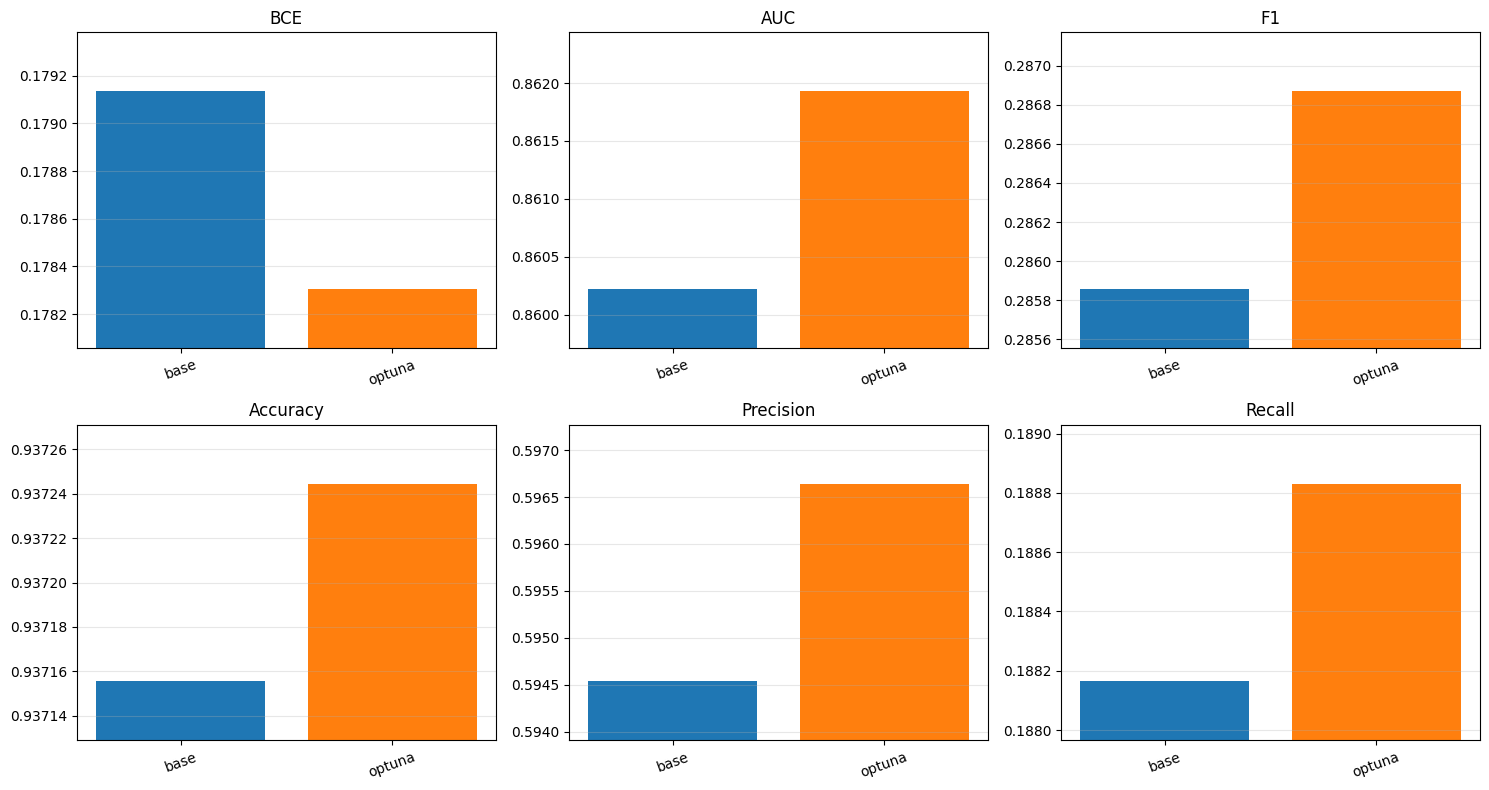

In [41]:
metrics_dict = {
    'base': lgbm_metrics,
    'optuna': lgbm_optuna_metrics
}

plot_metrics_from_dicts(metrics_dict)

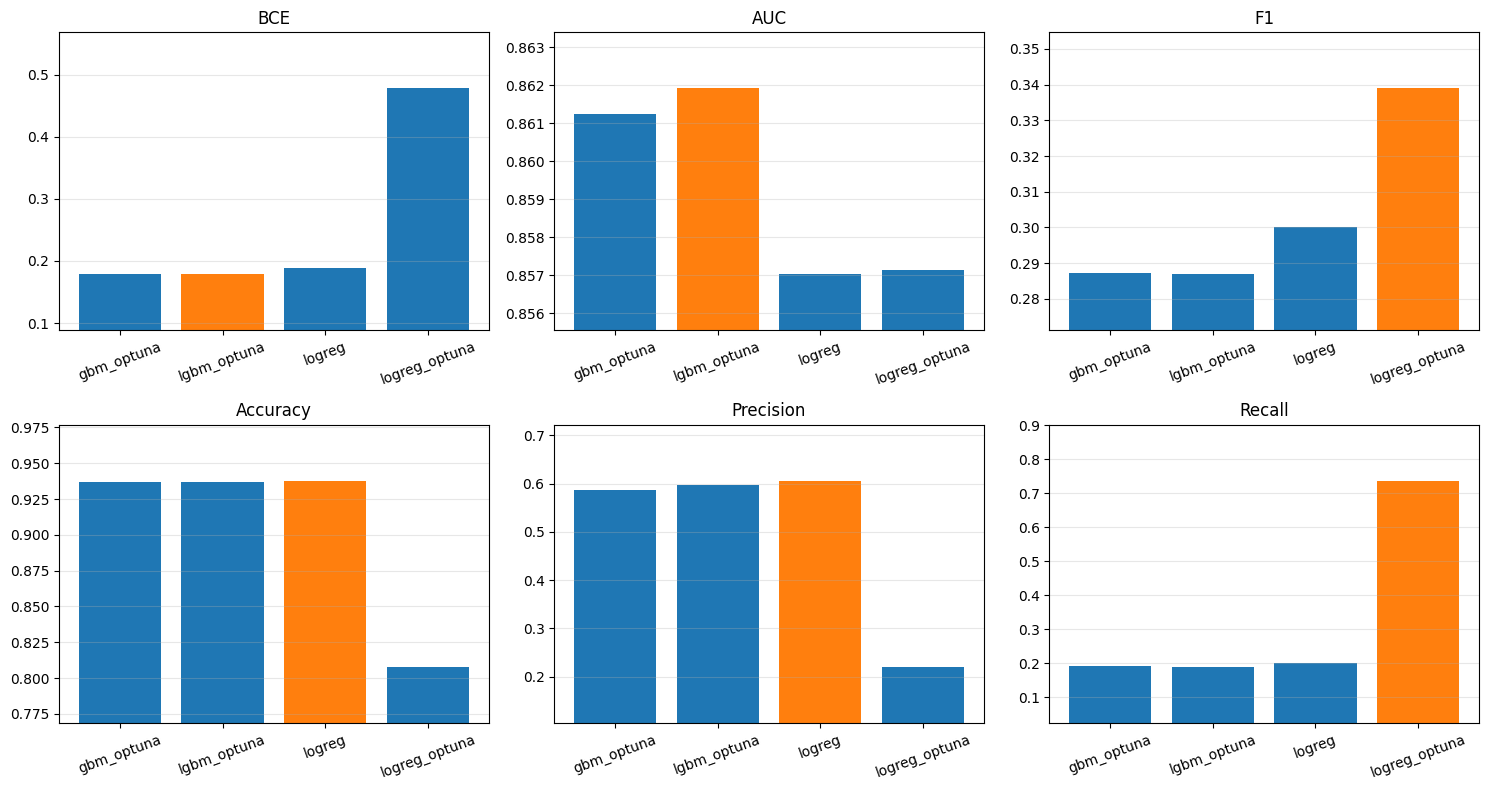

In [34]:
gbm_pipe_optuna = joblib.load('models/GBM/gbm_optuna.joblib')
logreg_pipe = joblib.load('models/LogReg/logreg.joblib')
logreg_pipe_optuna = joblib.load('models/LogReg/logreg_optuna.joblib')
lgbm_pipe_optuna = joblib.load('models/LGBM/lgbm_optuna.joblib')

gb_models = {'gbm_optuna': gbm_pipe_optuna, 'lgbm_optuna': lgbm_pipe_optuna}
logreg_models = {'logreg': logreg_pipe, 'logreg_optuna': logreg_pipe_optuna}

metrics_dict = {}


for model_name, model in gb_models.items(): 
    metrics = evaluate_model(
        model,
        X_fe2_fs_test, y_fe2_fs_test
    )
    metrics_dict[model_name] = metrics

for model_name, model in logreg_models.items(): 
    metrics = evaluate_model(
        model,
        X_fe_test, y_fe_test
    )
    metrics_dict[model_name] = metrics

plot_metrics_from_dicts(metrics_dict)

In [60]:
def objective_gbm_val(trial):
    params = {
        'model__n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'model__max_depth': trial.suggest_int('max_depth', 2, 5),
        'model__subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'model__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 30),
        'model__max_features': trial.suggest_categorical(
            'max_features',
            [None, 'sqrt', 'log2']
        ),
        'model__loss': trial.suggest_categorical(
            'loss',
            ['log_loss', 'exponential']
        ),
        'model__random_state': 42
    }

    pipe = make_gb_pipeline(
        GradientBoostingClassifier()
    )

    pipe.set_params(**params)
    pipe.fit(X_fe2_fs_train, y_fe2_fs_train)

    val_probs = pipe.predict_proba(X_fe2_fs_val)[:, 1]
    val_auc = roc_auc_score(y_fe2_fs_val, val_probs)

    return val_auc

In [61]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_gbm_val, n_trials=50)

best_params = {
    f'model__{k}': v for k, v in study.best_params.items()
}
print(f'Лучшие параметры: {best_params}')


gbm_val_pipe_optuna = make_gb_pipeline(
    GradientBoostingClassifier()
)
gbm_val_pipe_optuna.set_params(**best_params)

gbm_val_pipe_optuna.fit(X_fe2_fs_train, y_fe2_fs_train) 

gbm_val_optuna_metrics = evaluate_model(
    gbm_val_pipe_optuna,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(gbm_val_optuna_metrics)

[I 2026-04-07 21:05:24,450] A new study created in memory with name: no-name-1632370a-0b9d-48d1-9d5b-1d52c41a6532
[I 2026-04-07 21:05:30,539] Trial 0 finished with value: 0.8650456279919579 and parameters: {'n_estimators': 105, 'learning_rate': 0.0600994111827754, 'max_depth': 2, 'subsample': 0.9524833674709153, 'min_samples_split': 21, 'min_samples_leaf': 16, 'max_features': None, 'loss': 'log_loss'}. Best is trial 0 with value: 0.8650456279919579.
[I 2026-04-07 21:05:38,582] Trial 1 finished with value: 0.8690205809211886 and parameters: {'n_estimators': 302, 'learning_rate': 0.0214253557082102, 'max_depth': 4, 'subsample': 0.7021606405704364, 'min_samples_split': 34, 'min_samples_leaf': 19, 'max_features': 'sqrt', 'loss': 'exponential'}. Best is trial 1 with value: 0.8690205809211886.
[I 2026-04-07 21:05:45,980] Trial 2 finished with value: 0.8688403920908947 and parameters: {'n_estimators': 191, 'learning_rate': 0.12698404242862907, 'max_depth': 5, 'subsample': 0.7491582184974199, 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-07 21:09:55,086] Trial 23 finished with value: 0.8700760156189831 and parameters: {'n_estimators': 400, 'learning_rate': 0.03853601495217498, 'max_depth': 5, 'subsample': 0.9181297149815748, 'min_samples_split': 29, 'min_samples_leaf': 12, 'max_features': 'log2', 'loss': 'exponential'}. Best is trial 14 with value: 0.8705565877796377.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-07 21:10:04,917] Trial 24 finished with value: 0.8711105338453525 and parameters: {'n_estimators': 355, 'learning_rate': 0.05782358268270809, 'max_depth': 4, 'subsample': 0.8358693088008629, 'min_samples_split': 41, 'min_samples_leaf': 27, 'max_features': 'log2', 'loss': 'exponential'}. Best is trial 24 with value: 0.8711105338453525.
[I 2026-04-07 21:10:12,481] Trial 25 finished with value: 0.8704270196602798 and parameters: {'n_estimators': 281, 'learning_rate': 0.062380710105270944, 'max_depth': 4, 'subsample': 0.7746285772962541, 'min_samples_split': 42, 'min_samples_leaf': 27, 'max_features': 'sqrt', 'loss': 'exponential'}. Best is trial 24 with value: 0.8711105338453525.
[I 2026-04-07 21:10:23,988] Trial 26 finished with value: 0.8699034270205469 and parameters: {'n_estimators': 345, 'learning_rate': 0.08111278563159353, 'max_depth': 4, 'subsample': 0.6821458703767882, 'min_samples_split': 43, 'min_samples_leaf': 24, 'max_features': 'log2', 'loss': 'log_loss'}. Best is

Лучшие параметры: {'model__n_estimators': 355, 'model__learning_rate': 0.05782358268270809, 'model__max_depth': 4, 'model__subsample': 0.8358693088008629, 'model__min_samples_split': 41, 'model__min_samples_leaf': 27, 'model__max_features': 'log2', 'model__loss': 'exponential'}
{'AUC': 0.8629237065925425,
 'Accuracy': 0.9371555555555555,
 'BCE': 0.17840529382035897,
 'F1': 0.2887323943661972,
 'Precision': 0.5929752066115702,
 'Recall': 0.1908244680851064}


In [62]:
joblib.dump(gbm_val_pipe_optuna, 'models/GBM/gbm_val_optuna.joblib')

['models/GBM/gbm_val_optuna.joblib']

In [35]:
gbm_val_pipe_optuna = joblib.load('models/GBM/gbm_val_optuna.joblib')

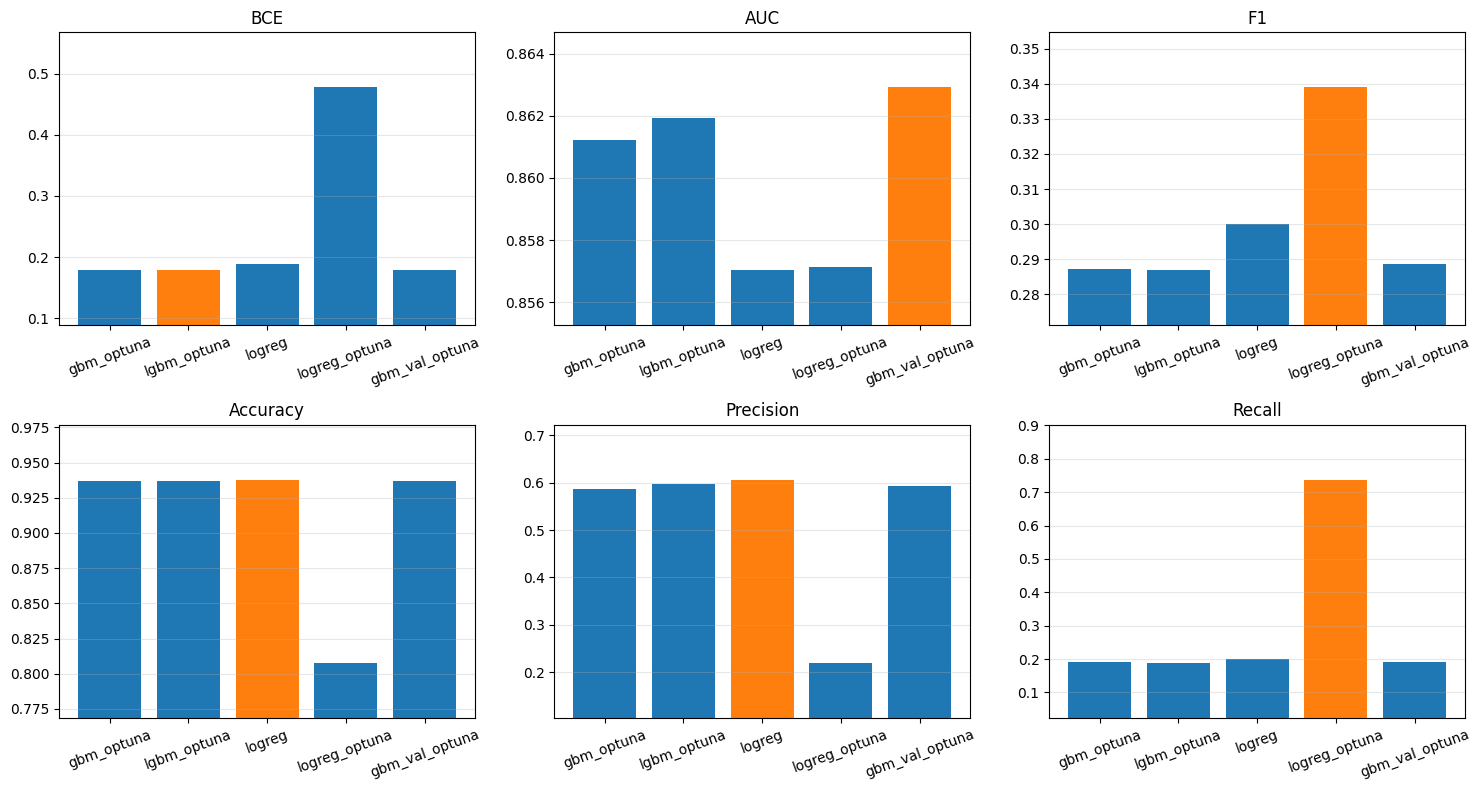

In [37]:
metrics_dict['gbm_val_optuna'] = gbm_val_optuna_metrics
plot_metrics_from_dicts(metrics_dict)

In [65]:
def objective_lgbm_val(trial):
    max_depth = trial.suggest_int('max_depth', 3, 6)

    params = {
        'model__n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'model__max_depth': max_depth,
        'model__num_leaves': trial.suggest_int('num_leaves', 4, min(2 ** max_depth, 64)),
        'model__subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'model__colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'model__min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'model__reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'model__reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'model__random_state': 42,
        'model__verbosity': -1,
        'model__objective': 'binary',
        'model__n_jobs': 1
    }

    pipe = make_gb_pipeline(
        LGBMClassifier()
    )

    pipe.set_params(**params)


    pipe.fit(
        X_fe2_fs_train,
        y_fe2_fs_train,
        model__eval_set=[(X_fe2_fs_val, y_fe2_fs_val)],
        model__eval_metric='auc'
    )

    val_probs = pipe.predict_proba(X_fe2_fs_val)[:, 1]
    val_auc = roc_auc_score(y_fe2_fs_val, val_probs)

    return val_auc

In [66]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_lgbm_val, n_trials=50)

best_params = {
    f'model__{k}': v for k, v in study.best_params.items()
}
print(f'Лучшие параметры: {best_params}')

lgbm_val_pipe_optuna = make_gb_pipeline(
    LGBMClassifier()
)
lgbm_val_pipe_optuna.set_params(**best_params)

lgbm_val_pipe_optuna.fit(
    X_fe2_fs_train,
    y_fe2_fs_train,
    model__eval_set=[(X_fe2_fs_val, y_fe2_fs_val)],
    model__eval_metric='auc'
)

lgbm_val_optuna_metrics = evaluate_model(
    lgbm_val_pipe_optuna,
    X_fe2_fs_test, y_fe2_fs_test
)
pprint(lgbm_val_optuna_metrics)

[I 2026-04-07 21:15:05,733] A new study created in memory with name: no-name-11d58cc3-eec7-4ab7-811c-b15a26d3e635
[I 2026-04-07 21:15:06,523] Trial 0 finished with value: 0.8697231748549875 and parameters: {'max_depth': 4, 'n_estimators': 105, 'learning_rate': 0.11964119032043544, 'num_leaves': 14, 'subsample': 0.6065613688520769, 'colsample_bytree': 0.8745796302676705, 'min_child_samples': 89, 'reg_alpha': 0.16871850826515333, 'reg_lambda': 0.1350856041234903}. Best is trial 0 with value: 0.8697231748549875.
[I 2026-04-07 21:15:07,320] Trial 1 finished with value: 0.8602836235524091 and parameters: {'max_depth': 5, 'n_estimators': 127, 'learning_rate': 0.012057115748365743, 'num_leaves': 6, 'subsample': 0.6267423348643711, 'colsample_bytree': 0.8588539530360484, 'min_child_samples': 98, 'reg_alpha': 0.199809006545888, 'reg_lambda': 0.17040476361221557}. Best is trial 0 with value: 0.8697231748549875.
[I 2026-04-07 21:15:09,774] Trial 2 finished with value: 0.8687242668816351 and param

Лучшие параметры: {'model__max_depth': 3, 'model__n_estimators': 209, 'model__learning_rate': 0.10644975014263804, 'model__num_leaves': 6, 'model__subsample': 0.9796598634541971, 'model__colsample_bytree': 0.9117614283621307, 'model__min_child_samples': 25, 'model__reg_alpha': 3.3379352534421574, 'model__reg_lambda': 0.024200615058752695}
{'AUC': 0.8623646462041402,
 'Accuracy': 0.9376888888888889,
 'BCE': 0.1779544264265434,
 'F1': 0.2940584088620342,
 'Precision': 0.6058091286307054,
 'Recall': 0.19414893617021275}


In [67]:
joblib.dump(lgbm_val_pipe_optuna, 'models/LGBM/lgbm_val_optuna.joblib')

['models/LGBM/lgbm_val_optuna.joblib']

In [38]:
lgbm_val_pipe_optuna = joblib.load('models/LGBM/lgbm_val_optuna.joblib')

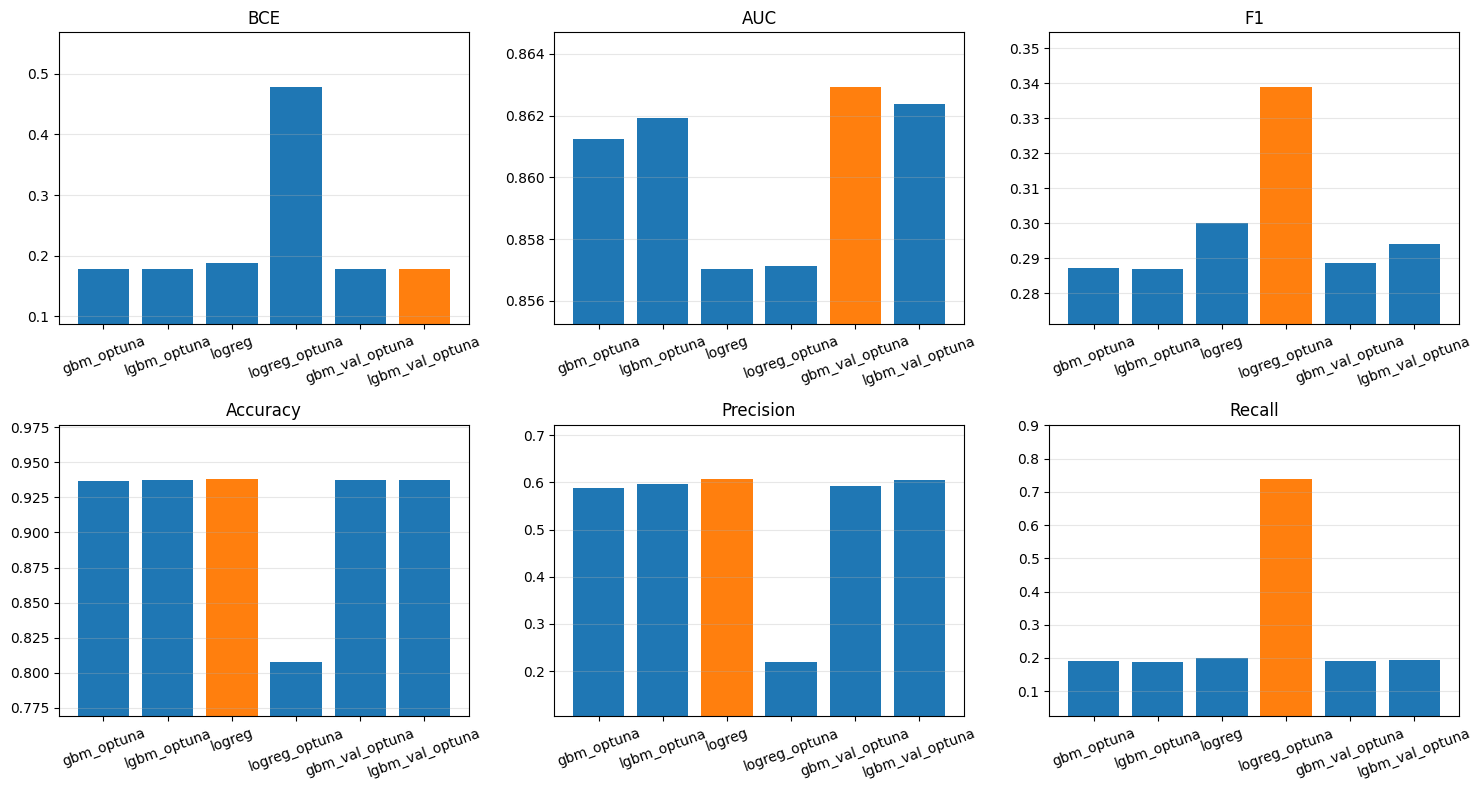

In [40]:
metrics_dict['lgbm_val_optuna'] = lgbm_val_optuna_metrics
plot_metrics_from_dicts(metrics_dict)

In [70]:
X_fe_test.columns

Index(['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
       'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
       'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
       'NumberOfDependents', 'MonthlyIncome_is_nan',
       'NumberOfDependents_is_nan', 'Revolving_high', 'Revolving_excess',
       'DebtRatio_high', 'Late_severity_log'],
      dtype='object')

In [71]:
X_fe2_fs_test.columns

Index(['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents',
       'MonthlyIncome_is_nan', 'NumberOfDependents_is_nan', 'Revolving_high',
       'Revolving_excess', 'DebtRatio_high', 'Late_severity_log',
       'Late_per_credit', 'Is_old'],
      dtype='object')

In [13]:
X_en_train = X_fe2_fs_train.copy()
X_en_val = X_fe2_fs_val.copy()
X_en_test = X_fe2_fs_test.copy()

X_en_train['DebtRatio'] = X_fe_train['DebtRatio']
X_en_val['DebtRatio'] = X_fe_val['DebtRatio']
X_en_test['DebtRatio'] = X_fe_test['DebtRatio']

In [19]:
class EnsembleClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        logreg_model,
        lgbm_model,
        gbm_model=None,
        logreg_columns=[
            'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
            'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
            'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
            'NumberOfDependents', 'MonthlyIncome_is_nan',
            'NumberOfDependents_is_nan', 'Revolving_high', 'Revolving_excess',
            'DebtRatio_high', 'Late_severity_log'
        ],
        boost_columns=[
            'RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome',
            'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
            'NumberRealEstateLoansOrLines', 'NumberOfDependents',
            'MonthlyIncome_is_nan', 'NumberOfDependents_is_nan', 'Revolving_high',
            'Revolving_excess', 'DebtRatio_high', 'Late_severity_log',
            'Late_per_credit', 'Is_old'
        ],
        threshold=0.5,
        weights=None
    ):
        self.logreg_model = logreg_model
        self.lgbm_model = lgbm_model
        self.gbm_model = gbm_model
        self.logreg_columns = logreg_columns
        self.boost_columns = boost_columns
        self.threshold = threshold
        self.weights = weights

    def predict_proba(self, X):
        probs = []

        X_logreg = X[self.logreg_columns] 
        X_boost = X[self.boost_columns]

        p_logreg = self.logreg_model.predict_proba(X_logreg)[:, 1]
        probs.append(p_logreg) 

        p_lgbm = self.lgbm_model.predict_proba(X_boost)[:, 1]
        probs.append(p_lgbm)

        p_gbm = self.gbm_model.predict_proba(X_boost)[:, 1]
        probs.append(p_gbm)

        probs = np.array(probs) 

        if self.weights is None:
            final_prob = np.mean(probs, axis=0)
        else:
            final_prob = np.average(probs, axis=0, weights=self.weights)

        return np.column_stack([1 - final_prob, final_prob])

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= self.threshold).astype(int)

In [20]:
weight_variants = []

step = 0.01

for w1 in np.arange(0, 1 + step, step):
    for w2 in np.arange(0, 1 - w1 + step, step):
        w3 = round(1 - w1 - w2, 10)

        if 0 <= w3 <= 1:
            weight_variants.append((w1, w2, w3))

print(f'Количество вариантов: {len(weight_variants)}')

Количество вариантов: 5151


In [21]:
p_logreg_val = logreg_pipe_optuna.predict_proba(X_fe_val)[:, 1]
p_lgbm_val = lgbm_pipe_optuna.predict_proba(X_fe2_fs_val)[:, 1]
p_gbm_val = gbm_pipe_optuna.predict_proba(X_fe2_fs_val)[:, 1]

In [22]:
best_auc = -1
best_weights = None

for w_logreg, w_lgbm, w_gbm in weight_variants:
    ensemble_probs = (
        w_logreg * p_logreg_val +
        w_lgbm * p_lgbm_val +
        w_gbm * p_gbm_val
    )

    auc = roc_auc_score(y_fe2_fs_val, ensemble_probs)

    if auc > best_auc:
        best_auc = auc
        best_weights = (w_logreg, w_lgbm, w_gbm)

print(f'Лучший AUC: {best_auc:.6f}')
print(f'Лучшие веса: {best_weights}')

Лучший AUC: 0.869838
Лучшие веса: (np.float64(0.01), np.float64(0.99), np.float64(0.0))


In [24]:
best_auc = -1
best_bce = float('inf')
best_f1 = -1
best_weights = None

auc_tolerance = 0.0005
bce_tolerance = 1e-4

for w_logreg, w_lgbm, w_gbm in weight_variants:
    ensemble_probs = (
        w_logreg * p_logreg_val +
        w_lgbm * p_lgbm_val +
        w_gbm * p_gbm_val
    )

    ensemble_preds = (ensemble_probs >= 0.5).astype(int)

    auc = roc_auc_score(y_fe2_fs_val, ensemble_probs)
    bce = log_loss(y_fe2_fs_val, ensemble_probs)
    f1 = f1_score(y_fe2_fs_val, ensemble_preds)

    if auc > best_auc + auc_tolerance:
        best_auc = auc
        best_bce = bce
        best_f1 = f1
        best_weights = (w_logreg, w_lgbm, w_gbm)

    elif abs(auc - best_auc) <= auc_tolerance:
        if bce < best_bce - bce_tolerance:
            best_bce = bce
            best_f1 = f1
            best_weights = (w_logreg, w_lgbm, w_gbm)

        elif abs(bce - best_bce) <= bce_tolerance and f1 > best_f1:
            best_f1 = f1
            best_weights = (w_logreg, w_lgbm, w_gbm)

print(f'Лучший AUC: {best_auc:.6f}')
print(f'Лучший BCE: {best_bce:.6f}')
print(f'Лучший F1: {best_f1:.6f}')
print(f'Лучшие веса: {best_weights}')

Лучший AUC: 0.869677
Лучший BCE: 0.175494
Лучший F1: 0.293560
Лучшие веса: (np.float64(0.0), np.float64(0.97), np.float64(0.03))


In [14]:
ensemble_model = EnsembleClassifier(
    logreg_model=logreg_pipe_optuna,
    lgbm_model=lgbm_val_pipe_optuna,
    gbm_model=gbm_val_pipe_optuna,
    weights=[0.01, 0.96, 0.03]
)

In [15]:
ensemble_metrics = evaluate_model(
    ensemble_model,
    X_en_test,
    y_fe2_fs_test
)

pprint(ensemble_metrics)

{'AUC': 0.8626627336311273,
 'Accuracy': 0.9377777777777778,
 'BCE': 0.177958921350418,
 'F1': 0.2978936810431294,
 'Precision': 0.6061224489795919,
 'Recall': 0.19747340425531915}


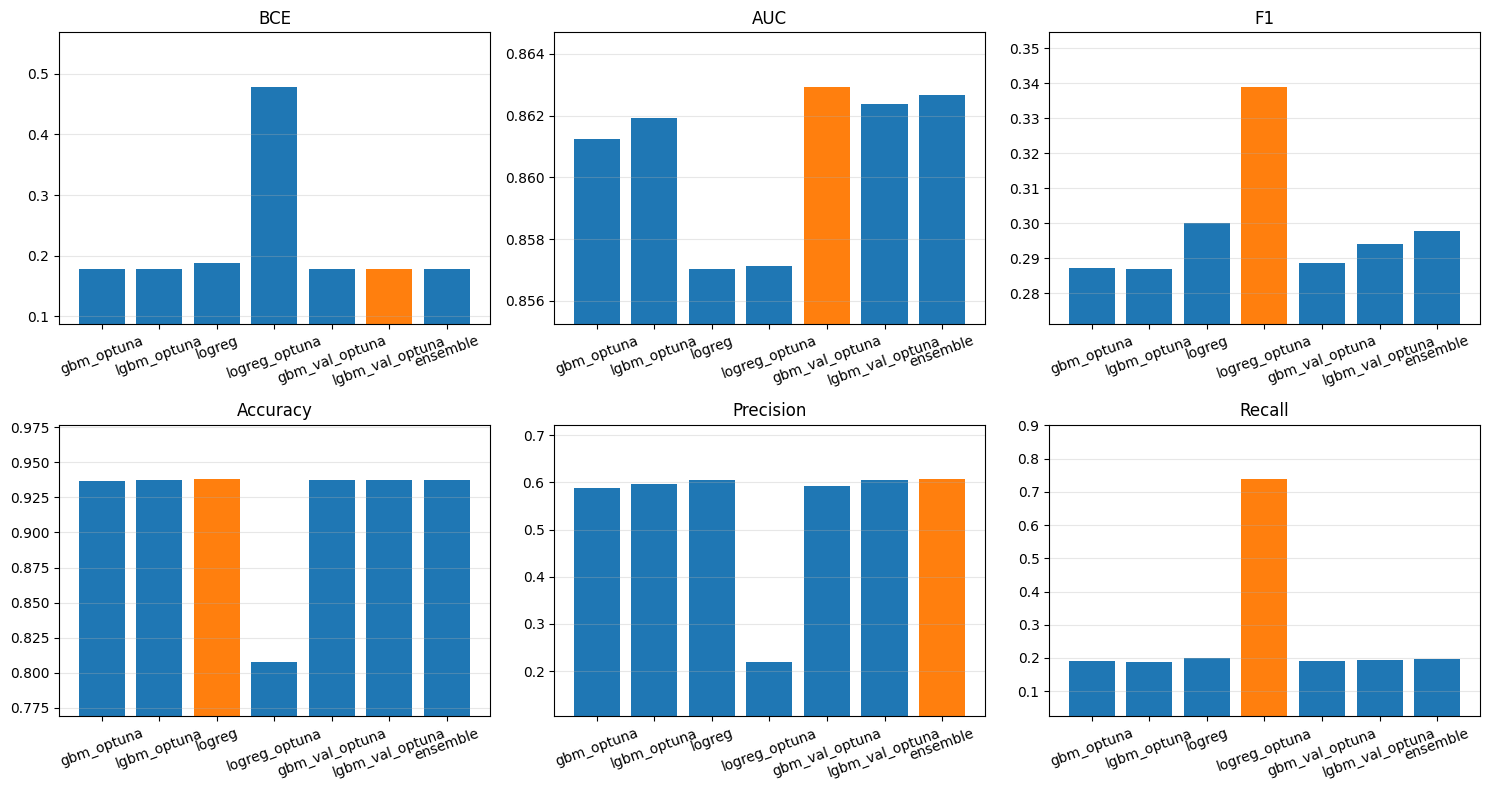

In [41]:
metrics_dict['ensemble'] = ensemble_metrics
plot_metrics_from_dicts(metrics_dict)

In [42]:
joblib.dump(ensemble_model, 'models/Ensemble/ensemble.pkl')

['models/Ensemble/ensemble.pkl']

In [43]:
boosting_ensemble = BoostingClassifier(
    lgbm_model=lgbm_val_pipe_optuna, 
    gbm_model=gbm_val_pipe_optuna, 
    w_lgbm=0.97, w_gbm=0.03
)

In [44]:
boosting_ensemble_metrics = evaluate_model(
    boosting_ensemble,
    X_fe2_fs_test,
    y_fe2_fs_test
)

pprint(boosting_ensemble_metrics)

{'AUC': 0.8624258755720442,
 'Accuracy': 0.9377777777777778,
 'BCE': 0.17794200304403987,
 'F1': 0.29506545820745217,
 'Precision': 0.6078838174273858,
 'Recall': 0.19481382978723405}


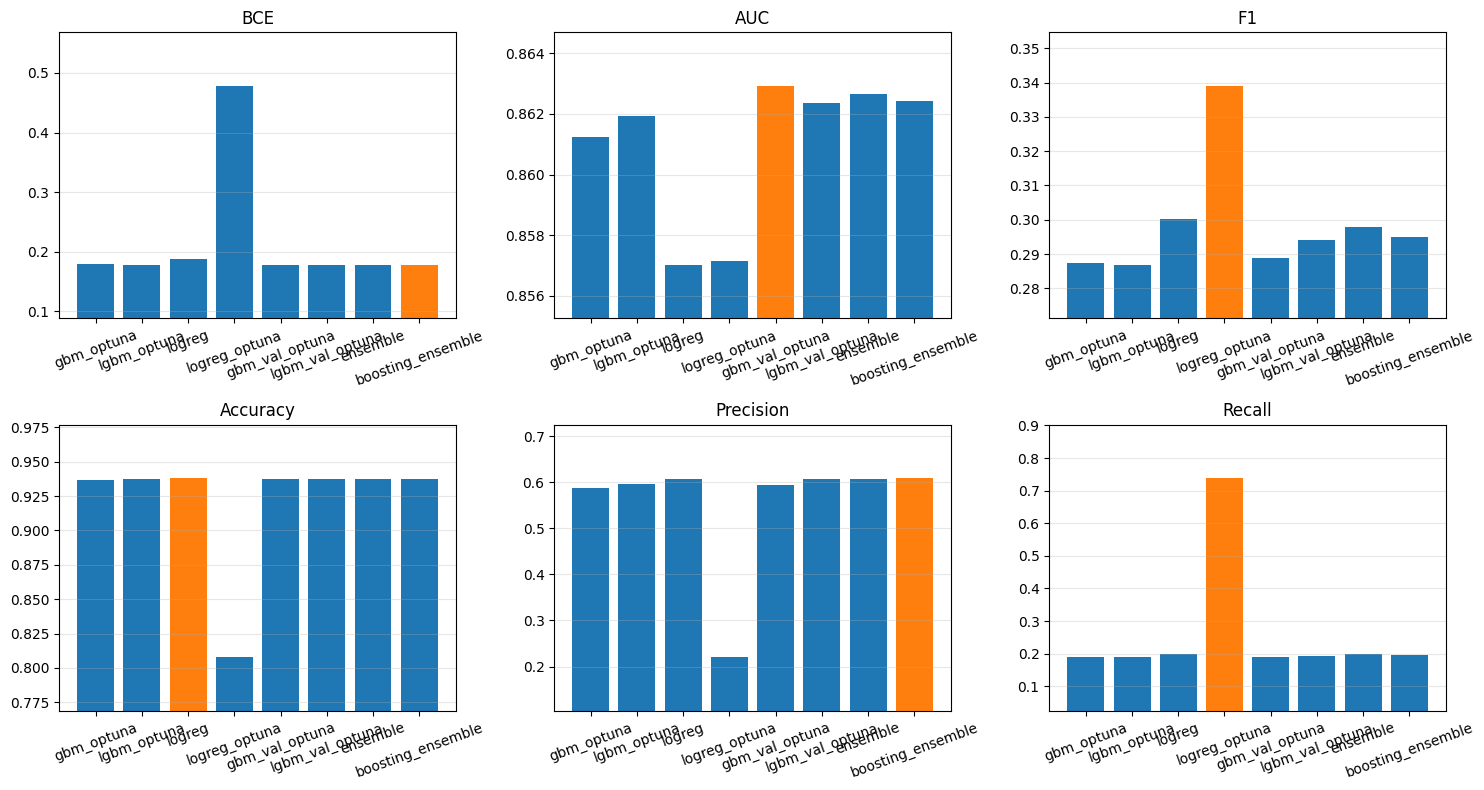

In [45]:
metrics_dict['boosting_ensemble'] = boosting_ensemble_metrics
plot_metrics_from_dicts(metrics_dict)

In [46]:
joblib.dump(boosting_ensemble, 'models/Ensemble/boosting_ensemble.pkl')

['models/Ensemble/boosting_ensemble.pkl']